In [16]:
!pip install -q ultralytics



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.7 MB/s eta 0:00:0000:0100:01


In [17]:
import os

cam = "/kaggle/input/datasets/a7madmostafa/bdd100k-yolo"

print(os.listdir(cam))

['data.yaml', 'val', 'test', 'train']


In [18]:
from ultralytics import YOLO

import yaml

with open("/kaggle/input/datasets/a7madmostafa/bdd100k-yolo/data.yaml") as f:
    print(yaml.safe_load(f))

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
{'path': '/kaggle/input/bdd100k-yolo', 'train': '/kaggle/input/bdd100k-yolo/train/images', 'val': '/kaggle/input/bdd100k-yolo/val/images', 'test': '/kaggle/input/bdd100k-yolo/test/images', 'nc': 10, 'names': ['person', 'rider', 'car', 'bus', 'truck', 'bike', 'motor', 'traffic light', 'traffic sign', 'train']}


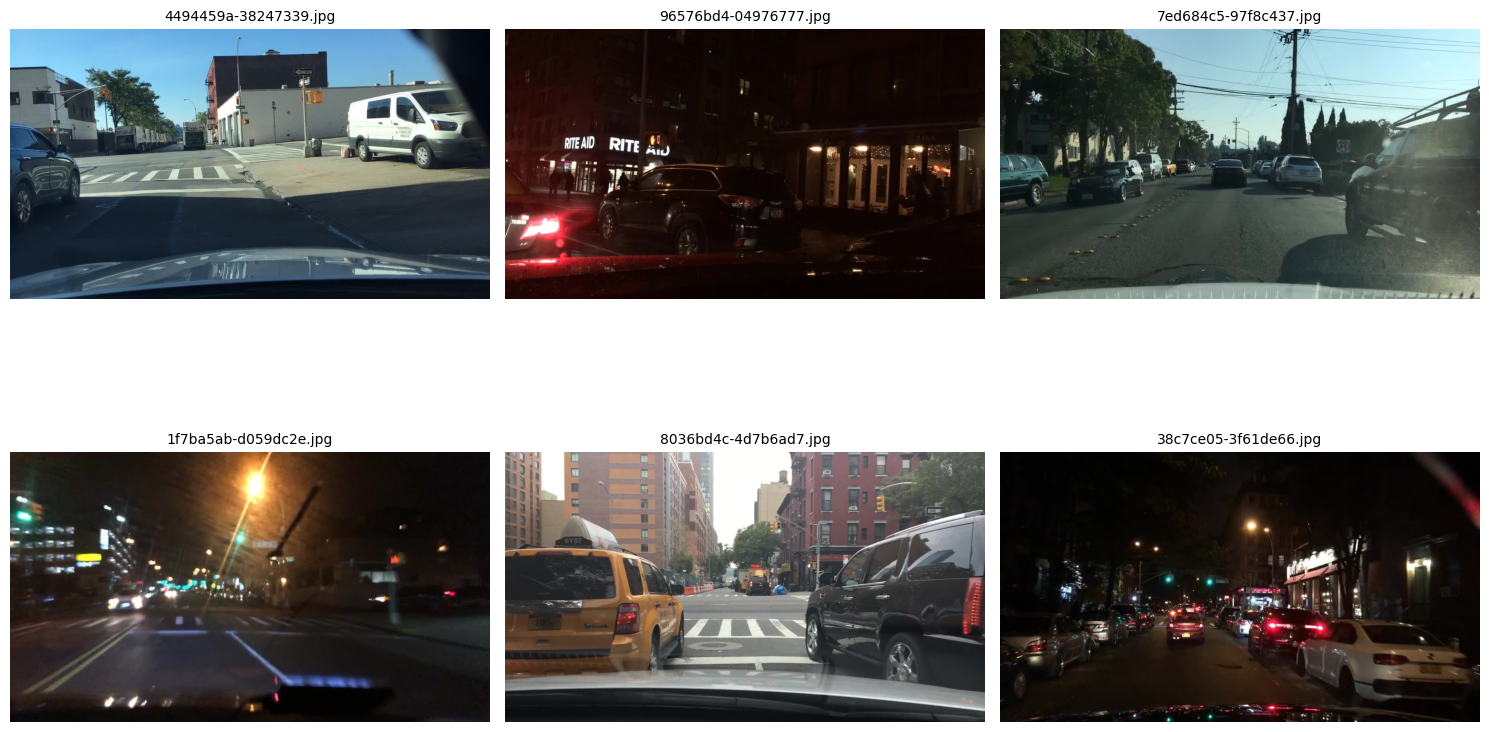

In [20]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Path to training images
train_img_dir = "/kaggle/input/datasets/a7madmostafa/bdd100k-yolo/train/images"

# Get all image files
image_files = [
    f for f in os.listdir(train_img_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Select 6 random images
random_images = random.sample(image_files, 6)

# Plot
plt.figure(figsize=(15, 10))

for i, img_name in enumerate(random_images):
    img_path = os.path.join(train_img_dir, img_name)
    img = Image.open(img_path)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(img_name, fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

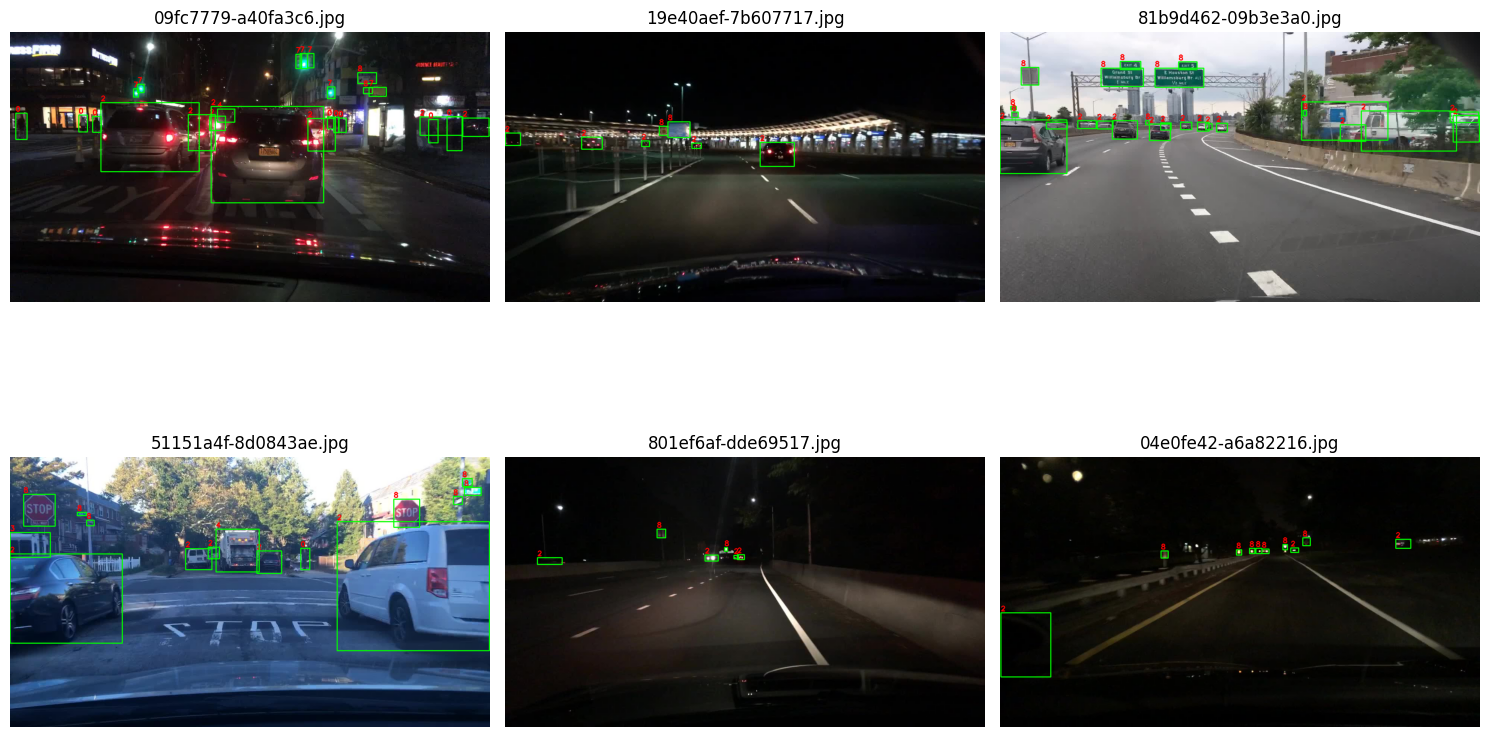

In [21]:
import os
import random
import cv2
import matplotlib.pyplot as plt

# Dataset paths
img_dir = "/kaggle/input/datasets/a7madmostafa/bdd100k-yolo/train/images"
label_dir = "/kaggle/input/datasets/a7madmostafa/bdd100k-yolo/train/labels"

images = [f for f in os.listdir(img_dir) if f.endswith((".jpg", ".png", ".jpeg"))]
samples = random.sample(images, 6)

plt.figure(figsize=(15, 10))

for i, img_name in enumerate(samples):
    img_path = os.path.join(img_dir, img_name)
    label_path = os.path.join(label_dir, os.path.splitext(img_name)[0] + ".txt")

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                cls, xc, yc, bw, bh = map(float, line.split())

                x1 = int((xc - bw/2) * w)
                y1 = int((yc - bh/2) * h)
                x2 = int((xc + bw/2) * w)
                y2 = int((yc + bh/2) * h)

                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img, str(int(cls)), (x1, y1 - 5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_name)

plt.tight_layout()
plt.show()

In [22]:
import torch

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.10.0+cu128
CUDA available: True
CUDA version: 12.8
GPU count: 2
GPU: Tesla T4


In [23]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model = YOLO("yolov8n.pt")


In [24]:
import os
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

base = "/kaggle/input/datasets/a7madmostafa/bdd100k-yolo"

print(os.path.exists(base))
print(os.path.exists(base + "/train/images"))
print(os.path.exists(base + "/val/images"))
print(os.path.exists(base + "/test/images"))

True
True
True
True


In [25]:
import yaml

new_yaml = {
    "path": "/kaggle/input/datasets/a7madmostafa/bdd100k-yolo",
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "nc": 10,
    "names": [
        "person",
        "rider",
        "car",
        "bus",
        "truck",
        "bike",
        "motor",
        "traffic light",
        "traffic sign",
        "train"
    ]
}

with open("/kaggle/working/data.yaml", "w") as f:
    yaml.dump(new_yaml, f)

print("New YAML created!")

New YAML created!


In [27]:
import yaml

yaml_file ="/kaggle/input/datasets/a7madmostafa/bdd100k-yolo/data.yaml"

with open(yaml_file) as f:
    data = yaml.safe_load(f)



print("Number of Classes:", data["nc"])
print()

print("Classes:")
for i, name in enumerate(data["names"]):
    print(f"{i} --> {name}")

Number of Classes: 10

Classes:
0 --> person
1 --> rider
2 --> car
3 --> bus
4 --> truck
5 --> bike
6 --> motor
7 --> traffic light
8 --> traffic sign
9 --> train


In [29]:


results = model.train(
    data="/kaggle/working/data.yaml",
    epochs=10,
    imgsz=640,
    batch=16,
    device=device,
    workers=2,
    save=True,
    save_period=1,
    verbose=True
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=N

In [30]:
from pathlib import Path
import shutil

train_dirs = sorted(Path("/kaggle/working/runs/detect").glob("train*"))

if not train_dirs:
    raise FileNotFoundError("No training folder found!")

latest = train_dirs[-1]
weights = latest / "weights"

print("Latest run:", latest)

if (weights / "best.pt").exists():
    shutil.copy(weights / "best.pt", "/kaggle/working/best.pt")
    shutil.copy(weights / "last.pt", "/kaggle/working/last.pt")
    print("✅ Done! best.pt and last.pt copied.")
else:
    print("❌ best.pt not found!")
    print("Files in weights:", list(weights.glob("*")))

Latest run: /kaggle/working/runs/detect/train-2
✅ Done! best.pt and last.pt copied.


In [33]:
import os

for root, dirs, files in os.walk("/kaggle/working/runs"):
    for f in files:
        if f.endswith(".pt"):
            print(os.path.join(root, f))

/kaggle/working/runs/detect/train-2/weights/best.pt
/kaggle/working/runs/detect/train-2/weights/epoch1.pt
/kaggle/working/runs/detect/train-2/weights/epoch6.pt
/kaggle/working/runs/detect/train-2/weights/epoch2.pt
/kaggle/working/runs/detect/train-2/weights/last.pt
/kaggle/working/runs/detect/train-2/weights/epoch5.pt
/kaggle/working/runs/detect/train-2/weights/epoch3.pt
/kaggle/working/runs/detect/train-2/weights/epoch4.pt
/kaggle/working/runs/detect/train-2/weights/epoch7.pt
/kaggle/working/runs/detect/train-2/weights/epoch9.pt
/kaggle/working/runs/detect/train-2/weights/epoch0.pt
/kaggle/working/runs/detect/train-2/weights/epoch8.pt


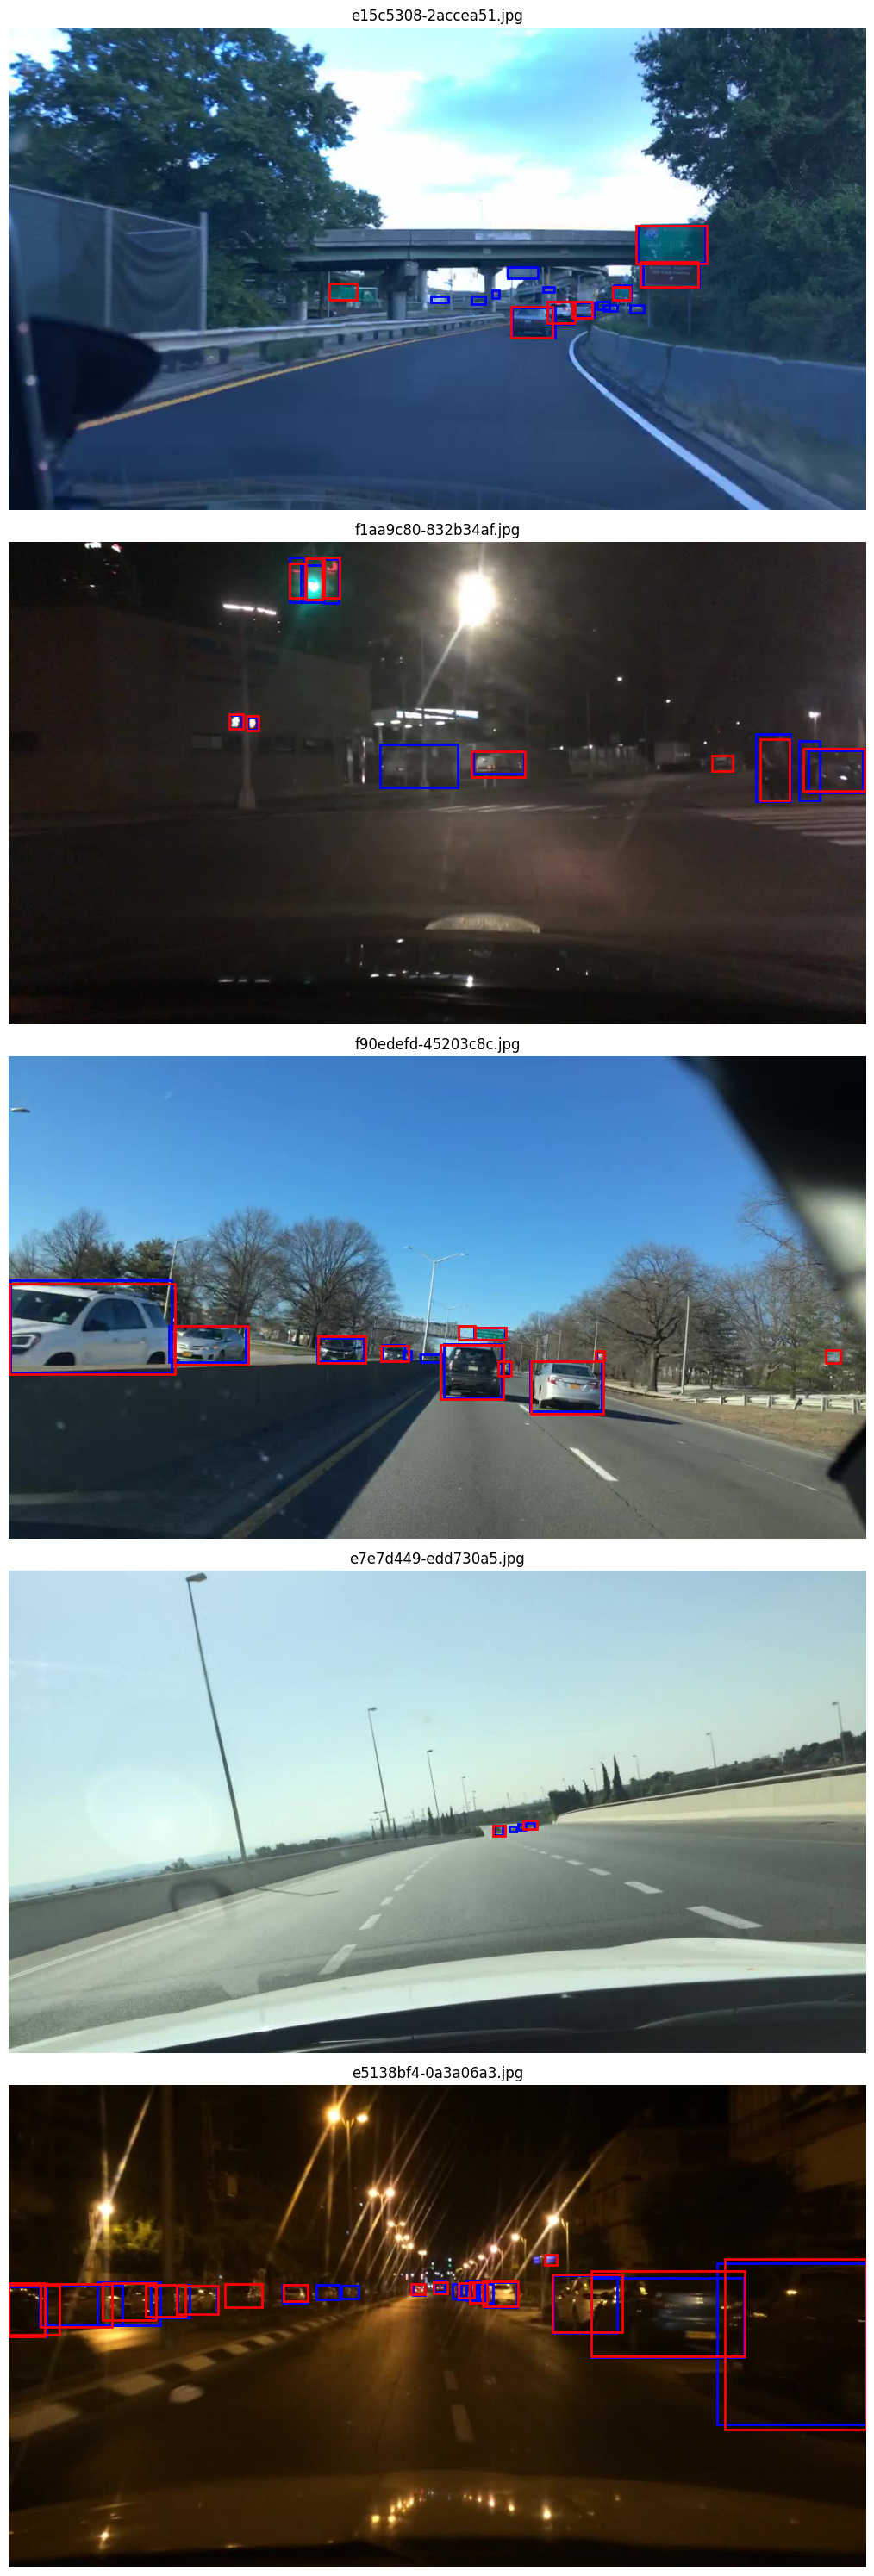

In [35]:
import random
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Paths
test_img_dir = Path("/kaggle/input/datasets/a7madmostafa/bdd100k-yolo/test/images")
test_lbl_dir = Path("/kaggle/input/datasets/a7madmostafa/bdd100k-yolo/test/labels")

# Randomly select 5 images
image_paths = random.sample(list(test_img_dir.glob("*")), 5)

fig, axes = plt.subplots(5, 1, figsize=(12, 30))

for ax, img_path in zip(axes, image_paths):

    # Read image
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # Run prediction
    result = model.predict(
        source=str(img_path),
        conf=0.25,
        verbose=False
    )[0]

    ax.imshow(img)

    # -------------------------
    # Ground Truth (Blue)
    # -------------------------
    label_path = test_lbl_dir / (img_path.stem + ".txt")

    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                cls, xc, yc, bw, bh = map(float, line.split())

                x1 = (xc - bw/2) * w
                y1 = (yc - bh/2) * h
                bw_pix = bw * w
                bh_pix = bh * h

                rect = patches.Rectangle(
                    (x1, y1),
                    bw_pix,
                    bh_pix,
                    linewidth=2,
                    edgecolor='blue',
                    facecolor='none'
                )
                ax.add_patch(rect)

    # -------------------------
    # Predictions (Red)
    # -------------------------
    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)

    ax.set_title(img_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()